In [142]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.io as sio
import scipy.signal
from scipy import *
import copy

from rich import print

## CREACIÓN DEL FILTRO - RESUMEN
- Seleccionar WINDOW SIZE (ej.: 80 puntos, k = 40)
- Convertir WINDOW SIZE a unidades de tiempo, dividiendo por SAMPLE_RATE  (ej.: 80/1000 Sa/s = 80 ms)
- Crear el *vector de tiempos* t:

    ```python 
    t = 1000 * np.arange(-k, k+1) / srate    # ms
    ```

- Seleccionar Full Width at Half Maximum FWHM (ej.: 25 ms) del filtro gausiano
- Crear el kernel gausiano:

    ```python
    gauswin = np.exp(-(4 * np.log(2) * t ** 2) / fwhm ** 2)   # vector de pesos del filtro
    gauswin_norm = gauswin / np.sum(gauswin)   # vector de pesos normalizado
    ``` 

- Aplicar el filtro a la señal

    ```python
    n = len(signal)  # signal[] = f(t[])

    filtsigG = signal.copy()  # initialize filtered signal

    for i in range(k+1, n-k):  #  i: punto central
        filtsigG[i] = np.sum(signal[ i-k : i+k+1 ] * gauswin)  # promedio ponderado 
    ``` 

In [143]:
def ejes():
    plt.axhline(0, color='black', lw=0.5)
    plt.axvline(0, color='black', lw=0.5)
    plt.grid(alpha=0.5)
    plt.tight_layout()

In [144]:
# Constants
PATH = "../@data/roz.csv"

In [145]:
df0 = pd.read_csv(PATH, sep="\t", header=0)
df0.head()

,ts,Sample#,A,B,dx,F
0,254451622.0,0.0,-43.75692,-29.44337,15.27346,0.09157
1,254451640.0,1.0,-43.76684,-29.44833,15.41719,0.08699
2,254451656.0,2.0,-43.71970,-29.43593,15.42845,0.08699
3,254451715.0,3.0,-43.75940,-29.46074,15.43485,0.08852
4,254451732.0,4.0,-43.70481,-29.45578,15.42967,0.08699


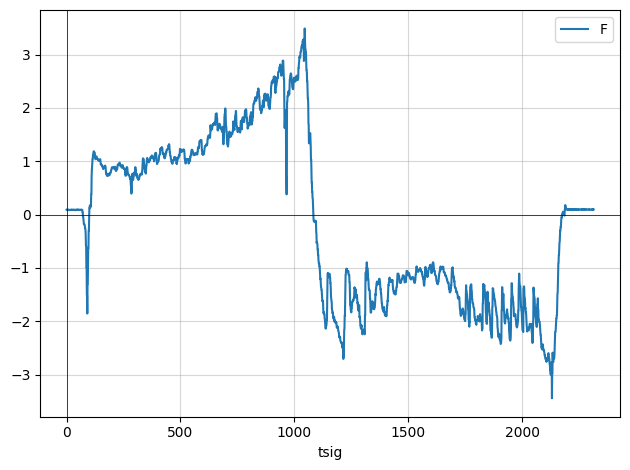

In [146]:
df0["tsig"] = df0["Sample#"] - df0["Sample#"][0]
df0.plot(x="tsig", y="F")
ejes()

In [147]:
# Aislamiento de la señal
tsig = np.array(df0["tsig"])
sig = np.array(df0["F"])
n = len(sig)
print(f"{n=}")

# Gaussian window
srate = 1000  # Hz

k = 80
ws = 1000 * np.arange(-k, k+1)  # window samples

tgauss = ws / srate
print(f'{tgauss=}')



n=2315

tgauss=array([-80., -79., -78., -77., -76., -75., -74., -73., -72., -71., -70.,
       -69., -68., -67., -66., -65., -64., -63., -62., -61., -60., -59.,
       -58., -57., -56., -55., -54., -53., -52., -51., -50., -49., -48.,
       -47., -46., -45., -44., -43., -42., -41., -40., -39., -38., -37.,
       -36., -35., -34., -33., -32., -31., -30., -29., -28., -27., -26.,
       -25., -24., -23., -22., -21., -20., -19., -18., -17., -16., -15.,
       -14., -13., -12., -11., -10.,  -9.,  -8.,  -7.,  -6.,  -5.,  -4.,
        -3.,  -2.,  -1.,   0.,   1.,   2.,   3.,   4.,   5.,   6.,   7.,
         8.,   9.,  10.,  11.,  12.,  13.,  14.,  15.,  16.,  17.,  18.,
        19.,  20.,  21.,  22.,  23.,  24.,  25.,  26.,  27.,  28.,  29.,
        30.,  31.,  32.,  33.,  34.,  35.,  36.,  37.,  38.,  39.,  40.,
        41.,  42.,  43.,  44.,  45.,  46.,  47.,  48.,  49.,  50.,  51.,
        52.,  53.,  54.,  55.,  56.,  57.,  58.,  59.,  60.,  61.,  62.,
        63.,  64.,  65.,  66.,  67.,  68.,  69.,  70.,  71.,  72.,  73.,
        74.,  75.,  76.,  77.,  78.,  79.,  80.])

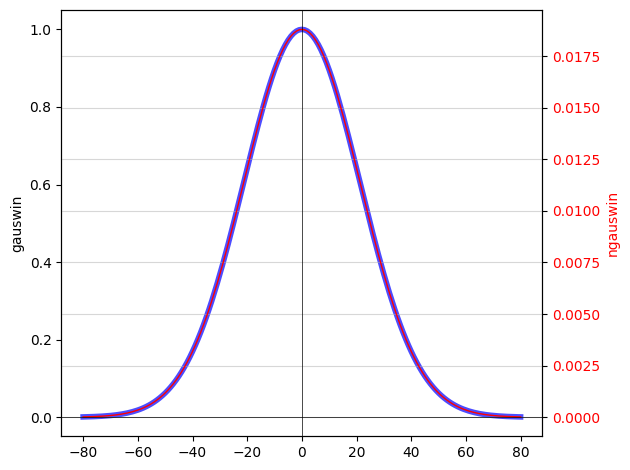

In [148]:
fwhm = 50

gauswin = np.exp(-(4 * np.log(2) * tgauss ** 2) / fwhm ** 2)

ngauswin = gauswin / np.sum(gauswin)

plt.plot(tgauss, gauswin, 'b', linewidth=4, alpha=0.7) # type: ignore
plt.ylabel('gauswin')
ax2 = plt.twinx()
ax2.plot(tgauss, ngauswin, 'r', linewidth=1) # type: ignore
ax2.set_ylabel('ngauswin', color='r')
ax2.tick_params(axis='y', labelcolor='r')
ejes()

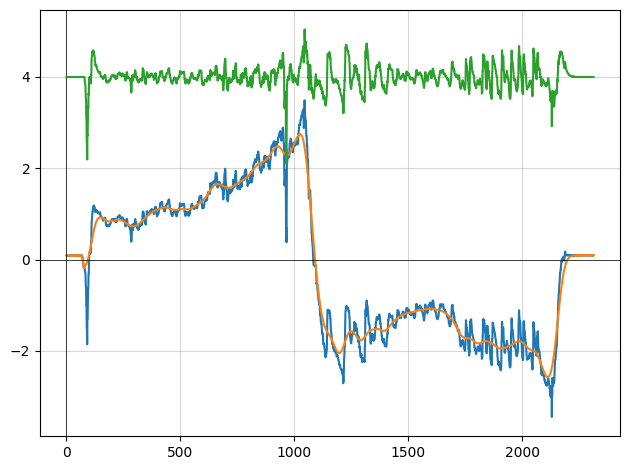

In [ ]:
# apply the filter
fsig = sig.copy()

for i in range(k, n-k):  # i varía en todo el dominio de la señal, excepto en los extremos (a los que sí llega i-k cuando i=0 e i+k cuando i=n-k)
    fsig[i] = np.sum(sig[i-k : i+k+1]*ngauswin)
    
plt.plot(tsig, sig)
plt.plot(tsig, fsig)
plt.plot(tsig, sig-fsig + 4)  

ejes()
plt.show()  

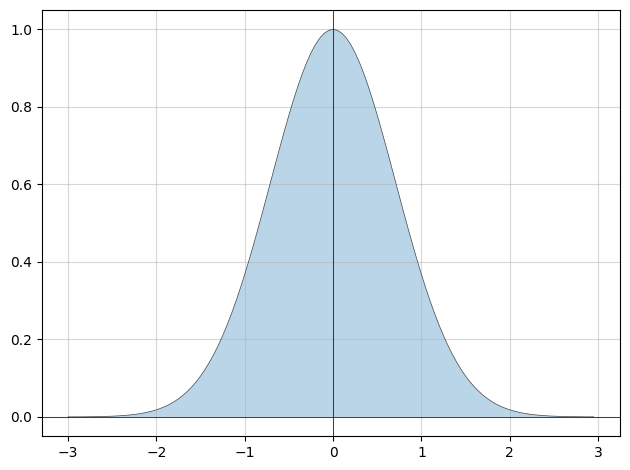

In [165]:
t = np.arange(-3, 3, 0.05)
y = np.exp(-t**2)
plt.fill_between(t, y, alpha=0.3)
plt.plot(t, y, 'k', linewidth=0.5, alpha=0.7) # type: ignore
ejes()